In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kimanaru/dataset-tien-xu-li/val_ml_clean_text.csv
/kaggle/input/datasets/kimanaru/dataset-tien-xu-li/train_ml_clean_text.csv
/kaggle/input/datasets/kimanaru/dataset-tien-xu-li/test_ml_clean_text.csv


In [2]:
import pandas as pd
from pathlib import Path

RESULT_DIR = Path("/kaggle/input/datasets/kimanaru/dataset-tien-xu-li")

train_df = pd.read_csv(RESULT_DIR / "train_ml_clean_text.csv")
val_df = pd.read_csv(RESULT_DIR / "val_ml_clean_text.csv")
test_df = pd.read_csv(RESULT_DIR / "test_ml_clean_text.csv")

train_df["ml_clean_text"] = train_df["ml_clean_text"].fillna("").astype(str)
val_df["ml_clean_text"] = val_df["ml_clean_text"].fillna("").astype(str)
test_df["ml_clean_text"] = test_df["ml_clean_text"].fillna("").astype(str)

train_df["category"] = train_df["category"].astype(str)
val_df["category"] = val_df["category"].astype(str)
test_df["category"] = test_df["category"].astype(str)

X_train = train_df["ml_clean_text"]
y_train = train_df["category"]

X_val = val_df["ml_clean_text"]
y_val = val_df["category"]

X_test = test_df["ml_clean_text"]
y_test = test_df["category"]

# Thử nghiệm 

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# =========================
# Cấu hình cố định
# =========================
SUBLINEAR_TF = True
C = 1.0
CLASS_WEIGHT = "balanced"
RANDOM_STATE = 42
MAX_ITER = 5000

# =========================
# Các thí nghiệm n-gram
# =========================
ngram_experiments = [
    {
        "experiment": "E1_unigram",
        "ngram_range": (1, 1)
    },
    {
        "experiment": "E2_unigram_bigram",
        "ngram_range": (1, 2)
    },
    {
        "experiment": "E3_unigram_bigram_trigram",
        "ngram_range": (1, 3)
    }
]

ngram_results = []

# =========================
# Chạy thí nghiệm
# =========================
for exp in ngram_experiments:
    print("=" * 80)
    print("Running:", exp["experiment"])

    tfidf = TfidfVectorizer(
        max_features= None,
        ngram_range=exp["ngram_range"],
        sublinear_tf=SUBLINEAR_TF
    )

    X_train_tfidf = tfidf.fit_transform(X_train)
    X_val_tfidf = tfidf.transform(X_val)

    model = LinearSVC(
        C=C,
        class_weight=CLASS_WEIGHT,
        random_state=RANDOM_STATE,
        max_iter=MAX_ITER
    )

    model.fit(X_train_tfidf, y_train)

    val_pred = model.predict(X_val_tfidf)

    result = {
        "experiment": exp["experiment"],
        "ngram_range": str(exp["ngram_range"]),
        "sublinear_tf": SUBLINEAR_TF,
        "C": C,
        "class_weight": CLASS_WEIGHT,
        "num_features": len(tfidf.get_feature_names_out()),
        "accuracy": accuracy_score(y_val, val_pred),
        "macro_precision": precision_score(
            y_val,
            val_pred,
            average="macro",
            zero_division=0
        ),
        "macro_recall": recall_score(
            y_val,
            val_pred,
            average="macro",
            zero_division=0
        ),
        "macro_f1": f1_score(
            y_val,
            val_pred,
            average="macro",
            zero_division=0
        ),
        "weighted_f1": f1_score(
            y_val,
            val_pred,
            average="weighted",
            zero_division=0
        )
    }

    ngram_results.append(result)

    print("Validation Accuracy:", result["accuracy"])
    print("Validation Macro F1:", result["macro_f1"])
    print("Number of features:", result["num_features"])

# =========================
# Tổng hợp kết quả
# =========================
ngram_results_df = pd.DataFrame(ngram_results)
ngram_results_df = ngram_results_df.sort_values(
    by="macro_f1",
    ascending=False
).reset_index(drop=True)

display(ngram_results_df)

Running: E1_unigram
Validation Accuracy: 0.724232604194797
Validation Macro F1: 0.6657138832981585
Number of features: 54811
Running: E2_unigram_bigram
Validation Accuracy: 0.7575839409487802
Validation Macro F1: 0.690077691860082
Number of features: 1113497
Running: E3_unigram_bigram_trigram
Validation Accuracy: 0.7537582140606716
Validation Macro F1: 0.6804556942061399
Number of features: 2632388


,experiment,ngram_range,sublinear_tf,C,class_weight,num_features,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,E2_unigram_bigram,"(1, 2)",True,1.0,balanced,1113497,0.757584,0.708880,0.687943,0.690078,0.749222
1,E3_unigram_bigram_trigram,"(1, 3)",True,1.0,balanced,2632388,0.753758,0.716460,0.677873,0.680456,0.742221
2,E1_unigram,"(1, 1)",True,1.0,balanced,54811,0.724233,0.656906,0.676369,0.665714,0.724957


Việc thêm trigram làm số lượng đặc trưng tăng rất mạnh nhưng không cải thiện hiệu quả mô hình, thậm chí làm Macro F1 giảm. Điều này cho thấy phần lớn cụm từ 3 không có giá trị phân biệt rõ ràng cho bài toán, do xuất hiện quá hiếm và làm tăng nhiễu trong không gian TF-IDF. Vì vậy, ngram_range=(1,2) là lựa chọn cân bằng phù hợp

Running max_features=10000
Validation Accuracy: 0.7130704833918444
Validation Macro F1: 0.6506568017560396
Number of features: 10000
Time seconds: 34.48
Running max_features=30000
Validation Accuracy: 0.7270681429471599
Validation Macro F1: 0.6666500680715344
Number of features: 30000
Time seconds: 36.15
Running max_features=50000
Validation Accuracy: 0.734359528310379
Validation Macro F1: 0.6738223074908561
Number of features: 50000
Time seconds: 41.74
Running max_features=100000
Validation Accuracy: 0.7466468629039518
Validation Macro F1: 0.6853667972158963
Number of features: 100000
Time seconds: 42.48
Running max_features=150000
Validation Accuracy: 0.748942299036817
Validation Macro F1: 0.6867792296660641
Number of features: 150000
Time seconds: 30.32
Running max_features=200000
Validation Accuracy: 0.7510126924115582
Validation Macro F1: 0.6881559286239636
Number of features: 200000
Time seconds: 29.09
Running max_features=300000
Validation Accuracy: 0.7533531370960482
Validation

,requested_max_features,num_features,ngram_range,sublinear_tf,C,class_weight,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,time_seconds
0,10000,10000,"(1, 2)",True,1.0,balanced,0.713070,0.639653,0.664460,0.650657,0.715290,34.475148
1,30000,30000,"(1, 2)",True,1.0,balanced,0.727068,0.659060,0.675801,0.666650,0.727808,36.153974
2,50000,50000,"(1, 2)",True,1.0,balanced,0.734360,0.668586,0.680691,0.673822,0.733904,41.740870
3,100000,100000,"(1, 2)",True,1.0,balanced,0.746647,0.683670,0.689437,0.685367,0.744511,42.479268
4,150000,150000,"(1, 2)",True,1.0,balanced,0.748942,0.687351,0.689706,0.686779,0.745741,30.324851
5,200000,200000,"(1, 2)",True,1.0,balanced,0.751013,0.690451,0.690319,0.688156,0.747211,29.094348
6,300000,300000,"(1, 2)",True,1.0,balanced,0.753353,0.695431,0.690327,0.689571,0.748266,31.783383
7,500000,500000,"(1, 2)",True,1.0,balanced,0.755604,0.700130,0.689515,0.689874,0.749126,34.951905
8,750000,750000,"(1, 2)",True,1.0,balanced,0.756549,0.702718,0.689106,0.689723,0.749185,37.315391
9,1000000,1000000,"(1, 2)",True,1.0,balanced,0.757449,0.707273,0.688374,0.690149,0.749395,39.107193


Best configuration based on validation Macro F1:
requested_max_features      1000000
num_features                1000000
ngram_range                  (1, 2)
sublinear_tf                   True
C                               1.0
class_weight               balanced
accuracy                   0.757449
macro_precision            0.707273
macro_recall               0.688374
macro_f1                   0.690149
weighted_f1                0.749395
time_seconds              39.107193
Name: 9, dtype: object


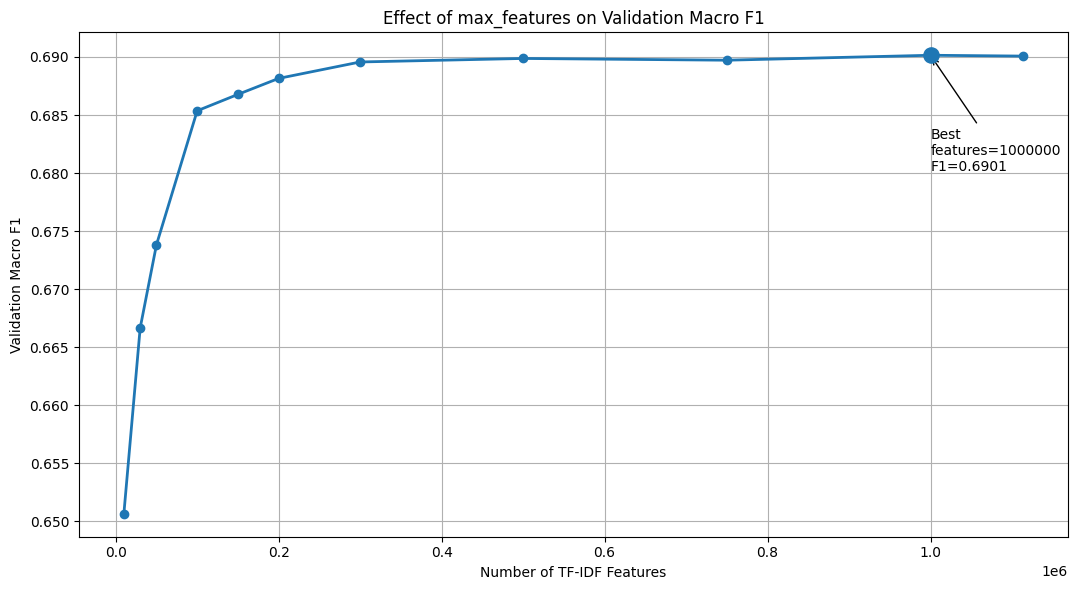

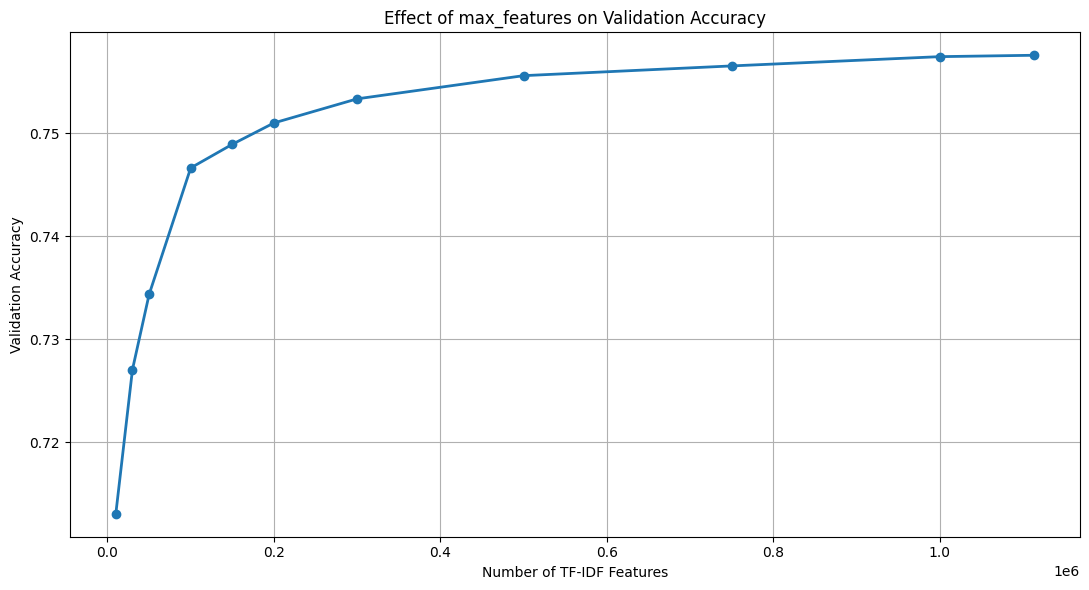

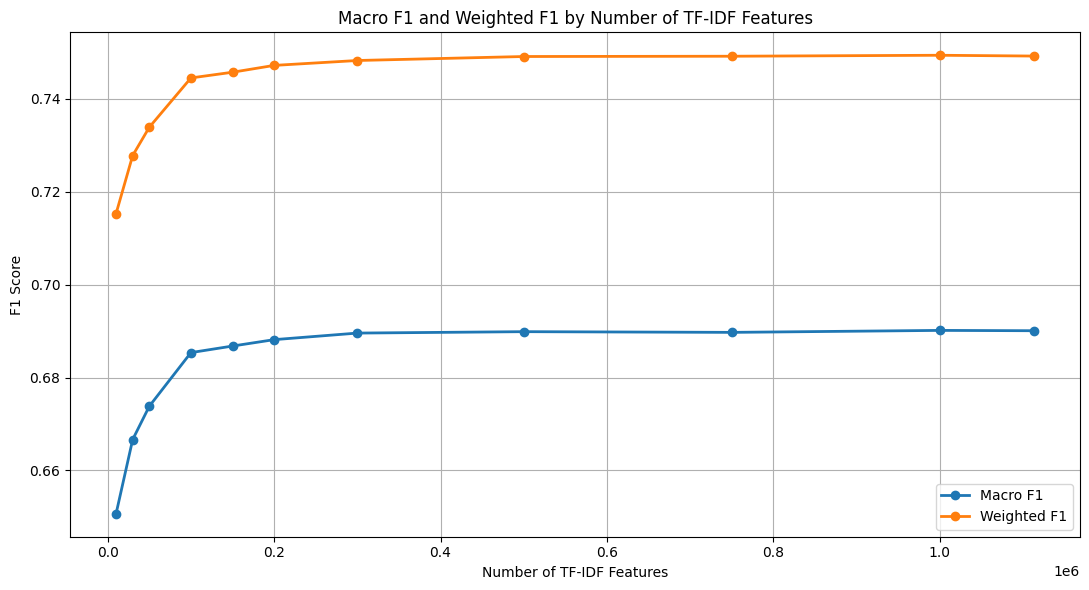

Saved results to: /kaggle/working/tfidf_max_features_no_df_filter


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import time

# =========================
# Tạo thư mục lưu kết quả
# =========================
RESULT_DIR = Path("/kaggle/working/tfidf_max_features_no_df_filter")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# Đảm bảo dữ liệu đúng định dạng
# =========================
X_train = X_train.fillna("").astype(str)
X_val = X_val.fillna("").astype(str)

y_train = y_train.astype(str)
y_val = y_val.astype(str)

# =========================
# Cấu hình cố định
# Bỏ min_df và max_df
# =========================
NGRAM_RANGE = (1, 2)
SUBLINEAR_TF = True

C = 1.0
CLASS_WEIGHT = "balanced"
RANDOM_STATE = 42
MAX_ITER = 5000

# =========================
# Các mức max_features cần thử
# Mốc cuối là 1,113,497
# =========================
max_features_values = [
    10000,
    30000,
    50000,
    100000,
    150000,
    200000,
    300000,
    500000,
    750000,
    1000000,
    1113497
]

max_features_results = []

# =========================
# Chạy thí nghiệm
# =========================
for max_features_value in max_features_values:
    print("=" * 80)
    print(f"Running max_features={max_features_value}")

    start_time = time.time()

    tfidf = TfidfVectorizer(
        max_features=max_features_value,
        ngram_range=NGRAM_RANGE,
        max_df = 0.8,
        sublinear_tf=SUBLINEAR_TF
    )

    X_train_tfidf = tfidf.fit_transform(X_train)
    X_val_tfidf = tfidf.transform(X_val)

    model = LinearSVC(
        C=C,
        class_weight=CLASS_WEIGHT,
        random_state=RANDOM_STATE,
        max_iter=MAX_ITER
    )

    model.fit(X_train_tfidf, y_train)

    val_pred = model.predict(X_val_tfidf)

    elapsed_time = time.time() - start_time

    result = {
        "requested_max_features": max_features_value,
        "num_features": len(tfidf.get_feature_names_out()),
        "ngram_range": str(NGRAM_RANGE),
        "sublinear_tf": SUBLINEAR_TF,
        "C": C,
        "class_weight": CLASS_WEIGHT,
        "accuracy": accuracy_score(y_val, val_pred),
        "macro_precision": precision_score(
            y_val,
            val_pred,
            average="macro",
            zero_division=0
        ),
        "macro_recall": recall_score(
            y_val,
            val_pred,
            average="macro",
            zero_division=0
        ),
        "macro_f1": f1_score(
            y_val,
            val_pred,
            average="macro",
            zero_division=0
        ),
        "weighted_f1": f1_score(
            y_val,
            val_pred,
            average="weighted",
            zero_division=0
        ),
        "time_seconds": elapsed_time
    }

    max_features_results.append(result)

    print("Validation Accuracy:", result["accuracy"])
    print("Validation Macro F1:", result["macro_f1"])
    print("Number of features:", result["num_features"])
    print("Time seconds:", round(result["time_seconds"], 2))

# =========================
# Tổng hợp kết quả
# =========================
max_features_results_df = pd.DataFrame(max_features_results)

max_features_results_df = max_features_results_df.sort_values(
    by="num_features"
).reset_index(drop=True)

display(max_features_results_df)

# =========================
# Lưu bảng kết quả
# =========================
max_features_results_df.to_csv(
    RESULT_DIR / "max_features_no_df_filter_results.csv",
    index=False,
    encoding="utf-8"
)

# =========================
# Tìm cấu hình tốt nhất theo Macro F1
# =========================
best_idx = max_features_results_df["macro_f1"].idxmax()
best_row = max_features_results_df.loc[best_idx]

print("=" * 80)
print("Best configuration based on validation Macro F1:")
print(best_row)

# =========================
# Vẽ biểu đồ Macro F1 theo số lượng đặc trưng
# =========================
plt.figure(figsize=(11, 6))

plt.plot(
    max_features_results_df["num_features"],
    max_features_results_df["macro_f1"],
    marker="o",
    linewidth=2
)

plt.scatter(
    best_row["num_features"],
    best_row["macro_f1"],
    s=120,
    zorder=5
)

plt.annotate(
    f"Best\nfeatures={int(best_row['num_features'])}\nF1={best_row['macro_f1']:.4f}",
    xy=(best_row["num_features"], best_row["macro_f1"]),
    xytext=(best_row["num_features"], best_row["macro_f1"] - 0.01),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

plt.xlabel("Number of TF-IDF Features")
plt.ylabel("Validation Macro F1")
plt.title("Effect of max_features on Validation Macro F1")
plt.grid(True)
plt.tight_layout()

plt.savefig(
    RESULT_DIR / "max_features_vs_macro_f1_no_df_filter.png",
    dpi=150
)

plt.show()

# =========================
# Vẽ biểu đồ Accuracy theo số lượng đặc trưng
# =========================
plt.figure(figsize=(11, 6))

plt.plot(
    max_features_results_df["num_features"],
    max_features_results_df["accuracy"],
    marker="o",
    linewidth=2
)

plt.xlabel("Number of TF-IDF Features")
plt.ylabel("Validation Accuracy")
plt.title("Effect of max_features on Validation Accuracy")
plt.grid(True)
plt.tight_layout()

plt.savefig(
    RESULT_DIR / "max_features_vs_accuracy_no_df_filter.png",
    dpi=150
)

plt.show()

# =========================
# Vẽ biểu đồ Macro F1 và Weighted F1
# =========================
plt.figure(figsize=(11, 6))

plt.plot(
    max_features_results_df["num_features"],
    max_features_results_df["macro_f1"],
    marker="o",
    linewidth=2,
    label="Macro F1"
)

plt.plot(
    max_features_results_df["num_features"],
    max_features_results_df["weighted_f1"],
    marker="o",
    linewidth=2,
    label="Weighted F1"
)

plt.xlabel("Number of TF-IDF Features")
plt.ylabel("F1 Score")
plt.title("Macro F1 and Weighted F1 by Number of TF-IDF Features")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    RESULT_DIR / "max_features_vs_f1_scores_no_df_filter.png",
    dpi=150
)

plt.show()

print("Saved results to:", RESULT_DIR)

max_features càng tăng → kết quả càng tốt.
10000 còn thiếu thông tin.
100000 là mức cân bằng tốt.
None đạt điểm cao nhất nhưng tốn tài nguyên hơn.

min_df=1: điểm cao nhất nhưng quá nhiều features.
min_df=2: gần bằng điểm tốt nhất, nhẹ hơn rất nhiều.
min_df=5 hoặc 10: lọc quá mạnh, làm mất thông tin.

In [5]:
# =========================
# Cấu hình TF-IDF cuối cùng
# =========================
tfidf_vectorizer = TfidfVectorizer(
    max_features= 300000,
    ngram_range=(1, 2),
    # min_df=2,
    max_df=0.8,
    sublinear_tf=True
)

In [6]:
# =========================
# Trích xuất đặc trưng TF-IDF
# =========================

# Fit chỉ trên train để tránh data leakage
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Validation và test chỉ transform
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("X_train_tfidf:", X_train_tfidf.shape)
print("X_val_tfidf:", X_val_tfidf.shape)
print("X_test_tfidf:", X_test_tfidf.shape)

print("Number of TF-IDF features:", len(tfidf_vectorizer.get_feature_names_out()))

X_train_tfidf: (103685, 300000)
X_val_tfidf: (22218, 300000)
X_test_tfidf: (22219, 300000)
Number of TF-IDF features: 300000


In [7]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.exceptions import ConvergenceWarning

import pandas as pd
import warnings

# =========================
# Đảm bảo nhãn đúng định dạng
# =========================
y_train = y_train.astype(str)
y_val = y_val.astype(str)

# =========================
# Các giá trị cần thử
# =========================
C_values = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
loss_values = ["squared_hinge", "hinge"]

CLASS_WEIGHT = "balanced"
RANDOM_STATE = 42
MAX_ITER = 5000

svc_results = []

# =========================
# Chạy thí nghiệm C và loss
# =========================
for C_value in C_values:
    for loss_value in loss_values:
        print("=" * 80)
        print(f"Running LinearSVC with C={C_value}, loss={loss_value}")

        model = LinearSVC(
            C=C_value,
            loss=loss_value,
            class_weight=CLASS_WEIGHT,
            random_state=RANDOM_STATE,
            max_iter=MAX_ITER,
            dual=True
        )

        with warnings.catch_warnings(record=True) as caught_warnings:
            warnings.simplefilter("always", ConvergenceWarning)

            model.fit(X_train_tfidf, y_train)

            convergence_warning = any(
                issubclass(w.category, ConvergenceWarning)
                for w in caught_warnings
            )

        val_pred = model.predict(X_val_tfidf)

        result = {
            "C": C_value,
            "loss": loss_value,
            "class_weight": CLASS_WEIGHT,
            "max_iter": MAX_ITER,
            "dual": True,
            "n_iter": model.n_iter_,
            "convergence_warning": convergence_warning,
            "accuracy": accuracy_score(y_val, val_pred),
            "macro_precision": precision_score(
                y_val,
                val_pred,
                average="macro",
                zero_division=0
            ),
            "macro_recall": recall_score(
                y_val,
                val_pred,
                average="macro",
                zero_division=0
            ),
            "macro_f1": f1_score(
                y_val,
                val_pred,
                average="macro",
                zero_division=0
            ),
            "weighted_f1": f1_score(
                y_val,
                val_pred,
                average="weighted",
                zero_division=0
            )
        }

        svc_results.append(result)

        print("Validation Accuracy:", result["accuracy"])
        print("Validation Macro F1:", result["macro_f1"])
        print("n_iter:", result["n_iter"])
        print("Convergence warning:", result["convergence_warning"])

# =========================
# Tổng hợp kết quả
# =========================
svc_results_df = pd.DataFrame(svc_results)

svc_results_df = svc_results_df.sort_values(
    by="macro_f1",
    ascending=False
).reset_index(drop=True)

display(svc_results_df)

Running LinearSVC with C=0.01, loss=squared_hinge
Validation Accuracy: 0.6975425330812854
Validation Macro F1: 0.6292440765603359
n_iter: 12
Convergence warning: False
Running LinearSVC with C=0.01, loss=hinge
Validation Accuracy: 0.6928166351606805
Validation Macro F1: 0.6206320275978509
n_iter: 100
Convergence warning: False
Running LinearSVC with C=0.1, loss=squared_hinge
Validation Accuracy: 0.7430461787739671
Validation Macro F1: 0.6792232668378023
n_iter: 17
Convergence warning: False
Running LinearSVC with C=0.1, loss=hinge
Validation Accuracy: 0.7095148078134845
Validation Macro F1: 0.6395794302224368
n_iter: 240
Convergence warning: False
Running LinearSVC with C=0.5, loss=squared_hinge
Validation Accuracy: 0.7542082995769196
Validation Macro F1: 0.690860807245674
n_iter: 49
Convergence warning: False
Running LinearSVC with C=0.5, loss=hinge
Validation Accuracy: 0.7389053920244847
Validation Macro F1: 0.6751086180265226
n_iter: 254
Convergence warning: False
Running LinearSVC 

,C,loss,class_weight,max_iter,dual,n_iter,convergence_warning,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,0.50,squared_hinge,balanced,5000,True,49,False,0.754208,0.693970,0.695104,0.690861,0.749166
1,1.00,squared_hinge,balanced,5000,True,84,False,0.753353,0.695431,0.690327,0.689571,0.748266
2,2.00,squared_hinge,balanced,5000,True,151,False,0.750743,0.694061,0.682198,0.684892,0.745224
3,1.00,hinge,balanced,5000,True,638,False,0.746692,0.678407,0.697158,0.684649,0.743654
4,2.00,hinge,balanced,5000,True,688,False,0.744982,0.680901,0.685197,0.680883,0.741723
5,0.10,squared_hinge,balanced,5000,True,17,False,0.743046,0.679772,0.690419,0.679223,0.737548
6,5.00,squared_hinge,balanced,5000,True,321,False,0.746017,0.691239,0.672147,0.678408,0.740063
7,10.00,squared_hinge,balanced,5000,True,578,False,0.743901,0.690359,0.667680,0.675648,0.737714
8,5.00,hinge,balanced,5000,True,1932,False,0.743001,0.687249,0.668947,0.675227,0.737753
9,0.50,hinge,balanced,5000,True,254,False,0.738905,0.668572,0.694915,0.675109,0.733923


Test metrics:
{'accuracy': 0.7612853863810253, 'macro_f1': 0.6987732437423259, 'weighted_f1': 0.7568096195894682, 'macro_precision': 0.7029985426195625, 'macro_recall': 0.7010299666455191}

Classification Report:
                precision    recall  f1-score   support

  BLACK VOICES       0.59      0.59      0.59       687
      BUSINESS       0.64      0.66      0.65       899
        COMEDY       0.63      0.55      0.59       810
 ENTERTAINMENT       0.81      0.77      0.79      2605
  FOOD & DRINK       0.75      0.83      0.79       951
HEALTHY LIVING       0.47      0.28      0.35      1004
 HOME & LIVING       0.79      0.79      0.79       648
     PARENTING       0.59      0.71      0.65      1319
       PARENTS       0.42      0.31      0.35       593
      POLITICS       0.90      0.88      0.89      5341
  QUEER VOICES       0.82      0.79      0.80       952
        SPORTS       0.78      0.84      0.81       761
STYLE & BEAUTY       0.84      0.87      0.86      1472
  

,precision,recall,f1-score,support
BLACK VOICES,0.590909,0.586608,0.588751,687.000000
BUSINESS,0.641246,0.664071,0.652459,899.000000
COMEDY,0.632857,0.546914,0.586755,810.000000
ENTERTAINMENT,0.811994,0.769290,0.790065,2605.000000
FOOD & DRINK,0.754036,0.834911,0.792415,951.000000
HEALTHY LIVING,0.465041,0.284861,0.353305,1004.000000
HOME & LIVING,0.786154,0.788580,0.787365,648.000000
PARENTING,0.592453,0.714177,0.647645,1319.000000
PARENTS,0.423888,0.305228,0.354902,593.000000
POLITICS,0.898214,0.875679,0.886803,5341.000000


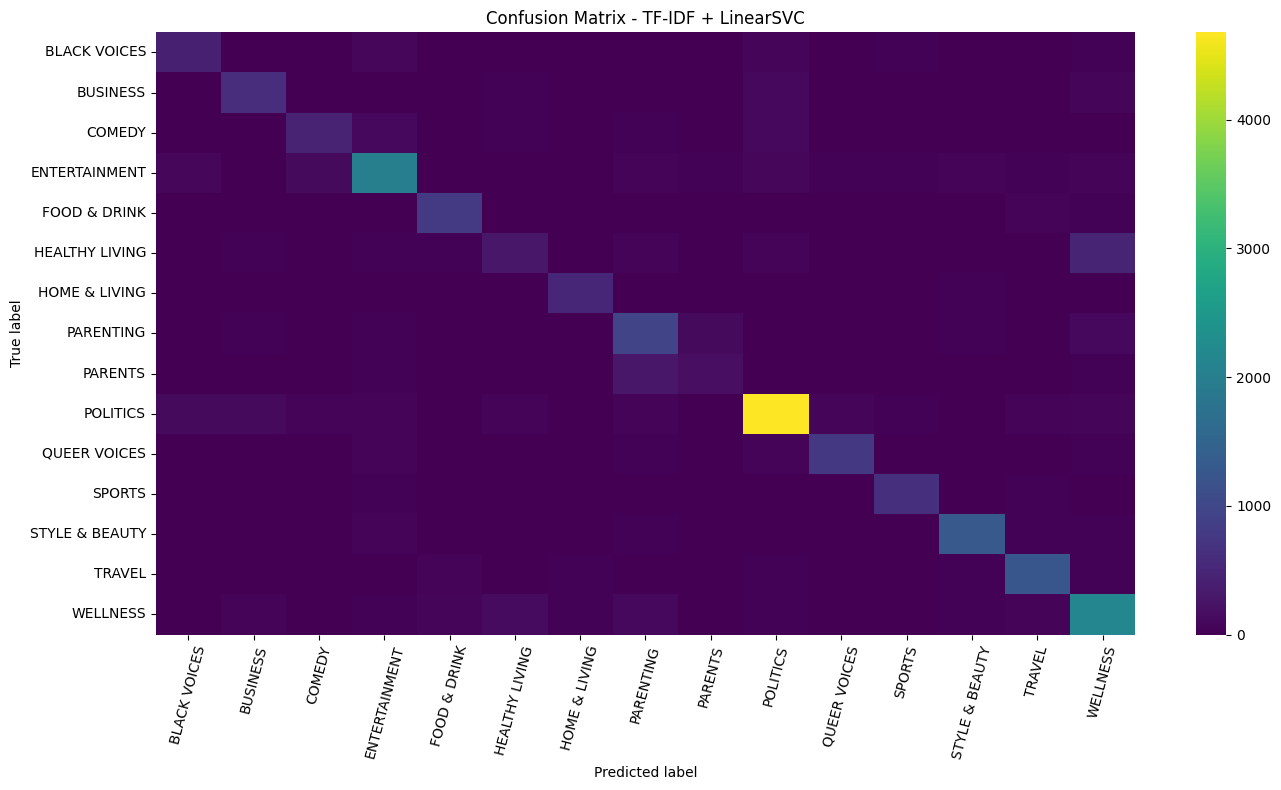

In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================
# Dự đoán trên tập test
# =========================
final_model = LinearSVC(
            C = 0.5,
            loss="squared_hinge",
            class_weight=CLASS_WEIGHT,
            random_state=RANDOM_STATE,
            max_iter=MAX_ITER,
            dual=True
)

final_model.fit(X_train_tfidf, y_train)
y_test_pred = final_model.predict(X_test_tfidf)

# =========================
# Tính các chỉ số đánh giá
# =========================
test_metrics = {
    "accuracy": accuracy_score(y_test, y_test_pred),
    "macro_f1": f1_score(y_test, y_test_pred, average="macro", zero_division=0),
    "weighted_f1": f1_score(y_test, y_test_pred, average="weighted", zero_division=0),
    "macro_precision": precision_score(y_test, y_test_pred, average="macro", zero_division=0),
    "macro_recall": recall_score(y_test, y_test_pred, average="macro", zero_division=0)
}

print("Test metrics:")
print(test_metrics)

# =========================
# Classification report
# =========================
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        zero_division=0
    )
)

# Lưu classification report thành DataFrame
report_dict = classification_report(
    y_test,
    y_test_pred,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()

display(report_df)

# =========================
# Confusion matrix
# =========================
target_names = sorted(y_test.unique())

cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=target_names
)

plt.figure(figsize=(14, 8))

sns.heatmap(
    cm,
    annot=False,
    fmt="d",
    cmap="viridis",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title("Confusion Matrix - TF-IDF + LinearSVC")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(rotation=75)
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig("confusion_matrix_tfidf_linearsvc.png", dpi=150)
plt.show()